In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\User\Downloads\archive (5)\aug_train.csv")

In [3]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


In [4]:
df.shape

(19158, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), object(10)
me

In [6]:
df.isnull().sum()

enrollee_id                  0
city                         0
city_development_index       0
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
last_new_job               423
training_hours               0
target                       0
dtype: int64

In [7]:
df_clean = df.copy()
cat_cols_with_nan = ['gender', 'enrolled_university', 'education_level', 
                    'major_discipline', 'company_size', 'company_type']
for col in cat_cols_with_nan:
    df_clean[col] = df_clean[col].fillna('Unknown')
    
df_clean['experience'] = df_clean['experience'].fillna(df_clean['experience'].mode()[0])
df_clean['last_new_job'] = df_clean['last_new_job'].fillna(df_clean['last_new_job'].mode()[0])

In [8]:
df_clean.isnull().sum().sum()

np.int64(0)

In [9]:
experience_map = {
    '<1': 0,
    '>20': 21
}
df_clean['experience_numeric'] = df_clean['experience'].replace(experience_map)
df_clean['experience_numeric'] = df_clean['experience_numeric'].astype(int)

In [10]:
df_clean.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,experience_numeric
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,Unknown,Unknown,1,36,1.0,21
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0,15
2,11561,city_21,0.624,Unknown,No relevent experience,Full time course,Graduate,STEM,5,Unknown,Unknown,never,83,0.0,5
3,33241,city_115,0.789,Unknown,No relevent experience,Unknown,Graduate,Business Degree,<1,Unknown,Pvt Ltd,never,52,1.0,0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0,21


In [11]:
last_job_map = {
    'never': 0,
    '1': 1,
    '2': 2,
    '3': 3,
    '4': 4,
    '>4': 5
}
df_clean['last_new_job_numeric'] = df_clean['last_new_job'].map(last_job_map)

In [12]:
df_clean.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,experience_numeric,last_new_job_numeric
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,Unknown,Unknown,1,36,1.0,21,1
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0,15,5
2,11561,city_21,0.624,Unknown,No relevent experience,Full time course,Graduate,STEM,5,Unknown,Unknown,never,83,0.0,5,0
3,33241,city_115,0.789,Unknown,No relevent experience,Unknown,Graduate,Business Degree,<1,Unknown,Pvt Ltd,never,52,1.0,0,0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0,21,4


In [13]:
def group_experience(exp):
    if exp <= 2:
        return 'Entry-level (0-2 yrs)'
    elif exp <= 5:
        return 'Junior (3-5 yrs)'
    elif exp <= 10:
        return 'Mid-level (6-10 yrs)'
    elif exp <= 15:
        return 'Senior (11-15 yrs)'
    else:
        return 'Expert (>15 yrs)'

df_clean['experience_group'] = df_clean['experience_numeric'].apply(group_experience)

In [14]:
df_clean.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,experience_numeric,last_new_job_numeric,experience_group
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,Unknown,Unknown,1,36,1.0,21,1,Expert (>15 yrs)
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0,15,5,Senior (11-15 yrs)
2,11561,city_21,0.624,Unknown,No relevent experience,Full time course,Graduate,STEM,5,Unknown,Unknown,never,83,0.0,5,0,Junior (3-5 yrs)
3,33241,city_115,0.789,Unknown,No relevent experience,Unknown,Graduate,Business Degree,<1,Unknown,Pvt Ltd,never,52,1.0,0,0,Entry-level (0-2 yrs)
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0,21,4,Expert (>15 yrs)


In [15]:
df_clean['target_label'] = df_clean['target'].map({0: 'Looking for Job', 1: 'Not Looking'})

In [16]:
df_clean.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,experience_numeric,last_new_job_numeric,experience_group,target_label
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,Unknown,Unknown,1,36,1.0,21,1,Expert (>15 yrs),Not Looking
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0,15,5,Senior (11-15 yrs),Looking for Job
2,11561,city_21,0.624,Unknown,No relevent experience,Full time course,Graduate,STEM,5,Unknown,Unknown,never,83,0.0,5,0,Junior (3-5 yrs),Looking for Job
3,33241,city_115,0.789,Unknown,No relevent experience,Unknown,Graduate,Business Degree,<1,Unknown,Pvt Ltd,never,52,1.0,0,0,Entry-level (0-2 yrs),Not Looking
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0,21,4,Expert (>15 yrs),Looking for Job


In [17]:
df_clean[['experience', 'experience_numeric', 'experience_group', 'last_new_job_numeric']].head()

,experience,experience_numeric,experience_group,last_new_job_numeric
0,>20,21,Expert (>15 yrs),1
1,15,15,Senior (11-15 yrs),5
2,5,5,Junior (3-5 yrs),0
3,<1,0,Entry-level (0-2 yrs),0
4,>20,21,Expert (>15 yrs),4


In [18]:
df_clean['target_label'].value_counts(normalize=True)*100

target_label
Looking for Job    75.065247
Not Looking        24.934753
Name: proportion, dtype: float64

C:\Users\User\AppData\Local\Temp\ipykernel_14996\3925153177.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_clean, x='target_label', palette=['#2b5c8f', '#d9534f'])


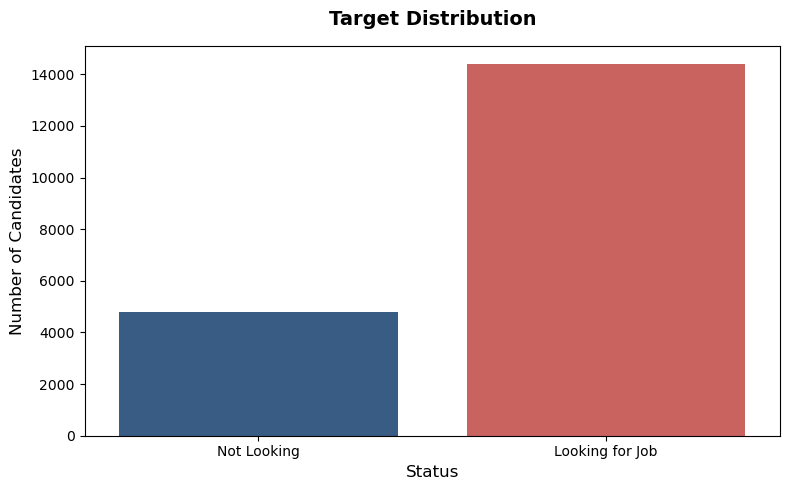

In [19]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_clean, x='target_label', palette=['#2b5c8f', '#d9534f'])

plt.title('Target Distribution', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Status', fontsize=12)
plt.ylabel('Number of Candidates', fontsize=12)
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_14996\4285727968.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_clean, x='experience_group', y='target', order=group_order, ci=None, palette='Blues_r')
C:\Users\User\AppData\Local\Temp\ipykernel_14996\4285727968.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='experience_group', y='target', order=group_order, ci=None, palette='Blues_r')


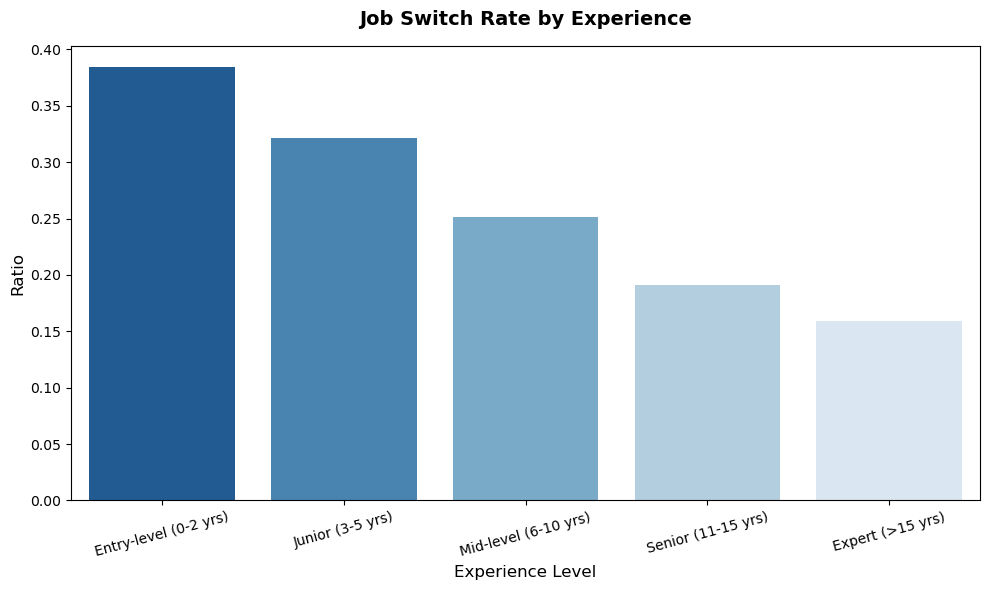

In [20]:
plt.figure(figsize=(10, 6))
group_order = ['Entry-level (0-2 yrs)', 'Junior (3-5 yrs)', 'Mid-level (6-10 yrs)', 'Senior (11-15 yrs)', 'Expert (>15 yrs)']

sns.barplot(data=df_clean, x='experience_group', y='target', order=group_order, ci=None, palette='Blues_r')

plt.title('Job Switch Rate by Experience', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Experience Level', fontsize=12)
plt.ylabel('Ratio', fontsize=12)
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_14996\3211064770.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='target_label', y='city_development_index', palette=['#2ece71', '#e74c3c'])


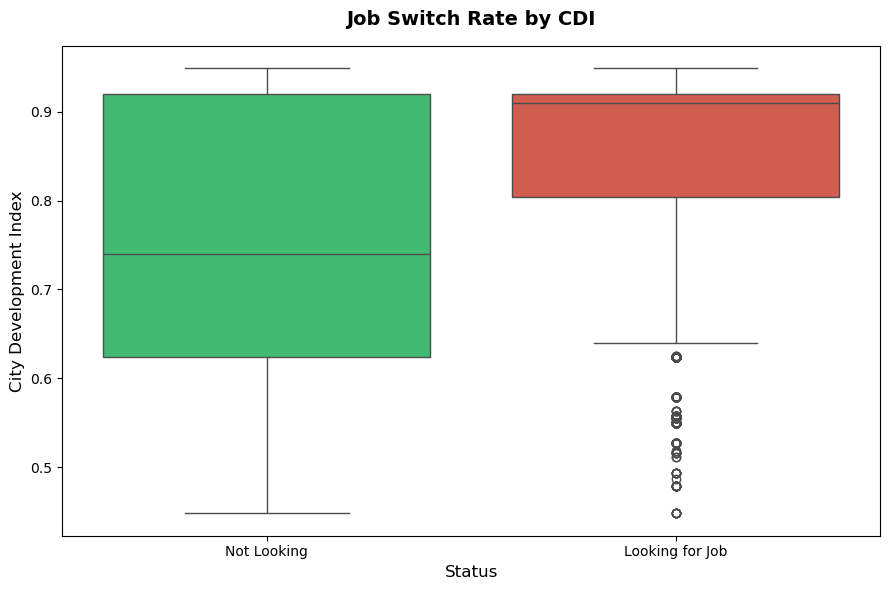

In [21]:
plt.figure(figsize=(9, 6))

sns.boxplot(data=df_clean, x='target_label', y='city_development_index', palette=['#2ece71', '#e74c3c'])

plt.title('Job Switch Rate by CDI', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Status', fontsize=12)
plt.ylabel('City Development Index', fontsize=12)
plt.tight_layout()
plt.show()

In [22]:
df_clean.to_csv("hr_analytics_clean.csv", index=False)